In [1]:
#1. Load the dataset and handle any missing data by replacing null values with the mean value of the respective column.
import pandas as pd
import numpy as np
df = pd.read_csv("winequality-red.csv", sep=";")
print(df.head())
print("Missing values before handling:")
print(df.isnull().sum())
df = df.fillna(df.mean(numeric_only=True))
print("Missing values after handling:")
print(df.isnull().sum())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [2]:
#2. Extract the following columns as vectors: alcohol,citric acid.
alcohol = df["alcohol"].values
citric_acid = df["citric acid"].values
print("Alcohol vector:")
print(alcohol)
print("\nCitric Acid vector:")
print(citric_acid)

Alcohol vector:
[ 9.4  9.8  9.8 ... 11.  10.2 11. ]

Citric Acid vector:
[0.   0.   0.04 ... 0.13 0.12 0.47]


In [3]:
#3. Select two features (e.g., alcohol and density) from the dataset and calculate the covariance matrix using np.cov(X.T), where X is the feature matrix consisting of the selected columns.

X = df[["alcohol", "density"]].values
cov_matrix = np.cov(X.T)
print("Covariance Matrix:")
print(cov_matrix)

Covariance Matrix:
[[ 1.13564740e+00 -9.97951790e-04]
 [-9.97951790e-04  3.56202945e-06]]


In [4]:
#4. Perform eigen decomposition on the covariance matrix you computed in question 3. Identify and interpret the results:Identify the top 2 eigenvalues of the covariance matrix,Identify the corresponding eigenvectors.

eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Eigenvalues:")
print(eigenvalues)
print("\nEigenvectors:")
print(eigenvectors)

Eigenvalues:
[1.13564827e+00 2.68507580e-06]

Eigenvectors:
[[ 9.99999614e-01  8.78753184e-04]
 [-8.78753184e-04  9.99999614e-01]]


In [5]:
#5. Which wine quality is most common in the dataset? How can you interpret the distribution of wine quality scores?

quality_counts = df["quality"].value_counts()
print("Wine quality distribution:")
print(quality_counts)
most_common_quality = df["quality"].mode()[0]
print("\nMost common wine quality:", most_common_quality)

Wine quality distribution:
quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

Most common wine quality: 5


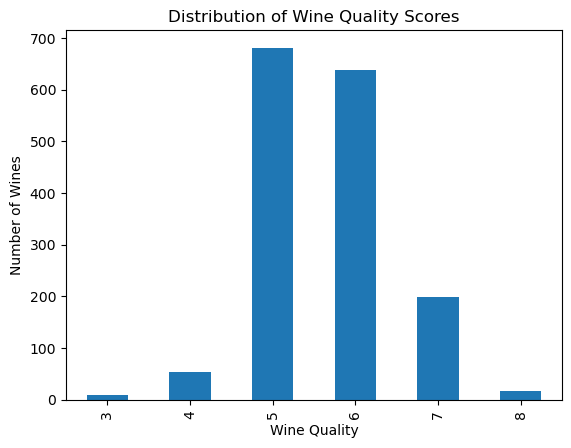

In [6]:
#visualization
import matplotlib.pyplot as plt
df["quality"].value_counts().sort_index().plot(kind="bar")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")
plt.title("Distribution of Wine Quality Scores")
plt.show()